## Example Decision Tree Structure for Capacity Risk

```text
Root
├── prb_util_dl <= 80?
│   ├── Yes
│   │   ├── active_users <= 65?
│   │   │   ├── Yes
│   │   │   │   ├── sinr_db > 14?
│   │   │   │   │   ├── Yes
│   │   │   │   │   │   ├── packet_loss <= 1.0?
│   │   │   │   │   │   │   ├── Yes
│   │   │   │   │   │   │   │   ├── latency_ms <= 40?
│   │   │   │   │   │   │   │   │   ├── Yes → capacity_risk = 0
│   │   │   │   │   │   │   │   │   └── No  → capacity_risk = 0
│   │   │   │   │   │   │   └── No  → capacity_risk = 1
│   │   │   │   │   └── No
│   │   │   │   │       ├── avg_mod_order <= 4?
│   │   │   │   │       │   ├── Yes → capacity_risk = 1
│   │   │   │   │       │   └── No  → capacity_risk = 0
│   │   │   └── No
│   │   │       ├── dl_throughput <= 25?
│   │   │       │   ├── Yes → capacity_risk = 1
│   │   │       │   └── No  → capacity_risk = 0
│   └── No
│       ├── packet_loss > 1.2?
│       │   ├── Yes
│       │   │   ├── latency_ms > 50?
│       │   │   │   ├── Yes → capacity_risk = 1
│       │   │   │   └── No  → capacity_risk = 1
│       │   └── No
│       │       ├── avg_mod_order <= 4?
│       │       │   ├── Yes → capacity_risk = 1
│       │       │   └── No  → capacity_risk = 0

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

In [8]:

# Load dataset from CSV
data = pd.read_csv("telecom_capacity_risk_dataset_300.csv")
print(data)

     prb_util_dl  prb_util_ul  active_users  sinr_db  avg_mod_order  \
0          88.26        50.92           100     6.45              2   
1          76.17        49.55            95    11.68              2   
2          59.71        39.13            66    15.93              4   
3          41.24        19.50            25    24.08              6   
4          68.09        45.65            85    11.42              4   
..           ...          ...           ...      ...            ...   
295        58.36        37.69            69    16.84              6   
296        32.16        25.23            35    22.69              6   
297        90.03        54.15           108     8.72              2   
298        64.12        38.82            67    16.77              8   
299        53.12        36.71            45    17.02              6   

     packet_loss  latency_ms  drop_call_rate  dl_throughput  weekend  \
0          0.593       26.87           0.686           3.00        0   
1  

In [3]:
# Features and target
X = data.drop("capacity_risk", axis=1)
y = data["capacity_risk"]

In [4]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

In [5]:
# Model
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=42
)
model.fit(X_train, y_train)

RandomForestClassifier(max_depth=6, n_estimators=200, random_state=42)

In [6]:
# Predictions
y_pred = model.predict(X_test)

In [7]:
# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Feature importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance:\n", importance)

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0

Confusion Matrix:
 [[39  0]
 [ 0 36]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        39
           1       1.00      1.00      1.00        36

    accuracy                           1.00        75
   macro avg       1.00      1.00      1.00        75
weighted avg       1.00      1.00      1.00        75


Feature Importance:
           Feature  Importance
8   dl_throughput    0.444705
3         sinr_db    0.191469
2    active_users    0.128922
0     prb_util_dl    0.068831
6      latency_ms    0.060586
1     prb_util_ul    0.046801
4   avg_mod_order    0.042972
7  drop_call_rate    0.010984
5     packet_loss    0.004044
9         weekend    0.000687


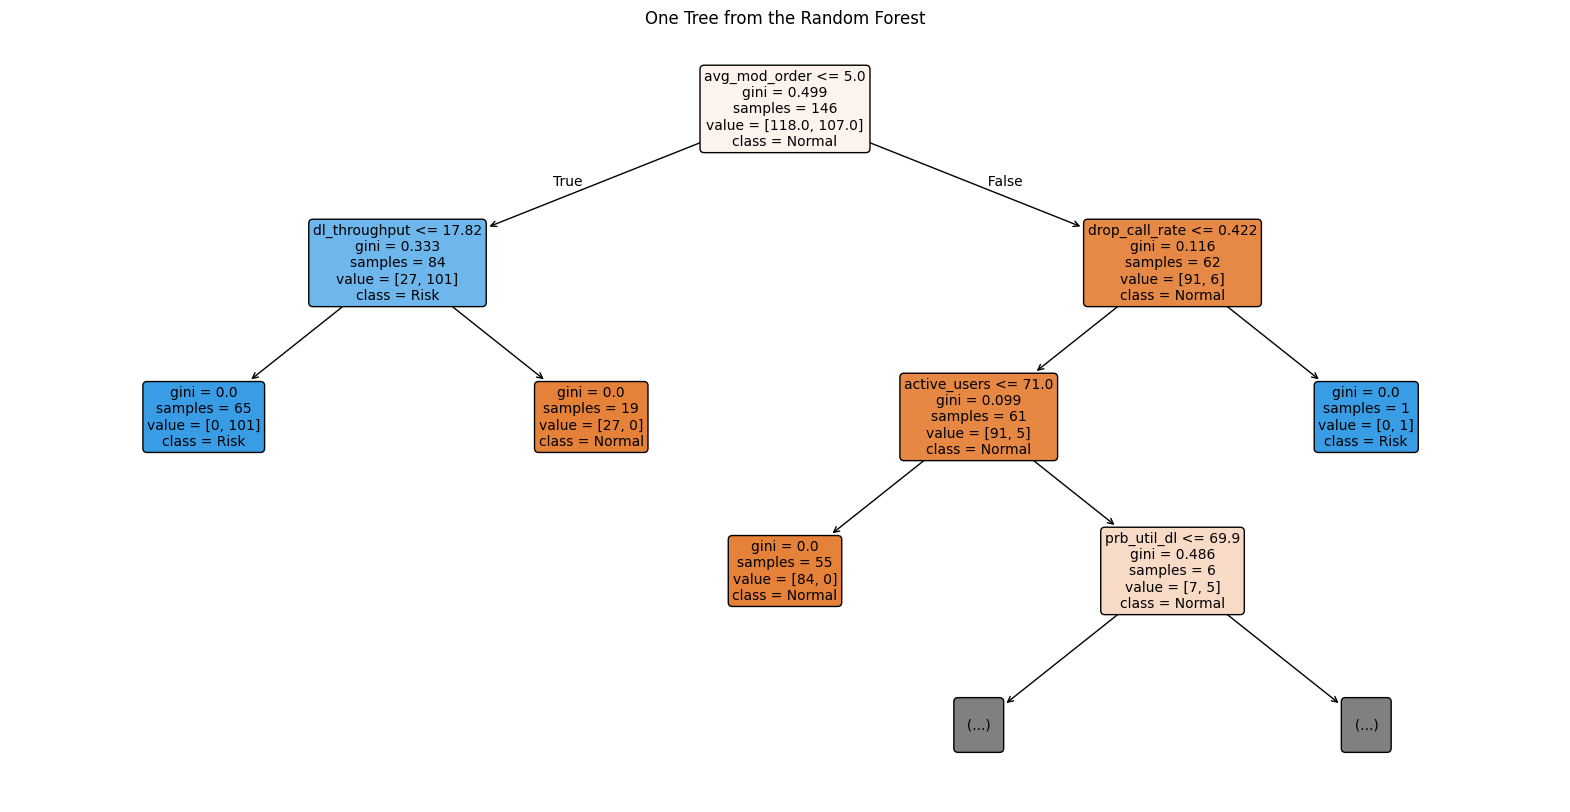

In [9]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Plot the first tree in the forest
plt.figure(figsize=(20, 10))
plot_tree(
    model.estimators_[0],
    feature_names=X.columns,
    class_names=["Normal", "Risk"],
    filled=True,
    rounded=True,
    max_depth=3,   # only show top levels for readability
    fontsize=10
)
plt.title("One Tree from the Random Forest")
plt.show()

In [13]:
# This is the Gini impurity
# It measures how mixed the classes are at that node.
#      gini = 0 → all samples belong to one class only
#      higher gini → more mixed classes
#      So 0.499 means the root node is quite mixed between Normal and Risk.

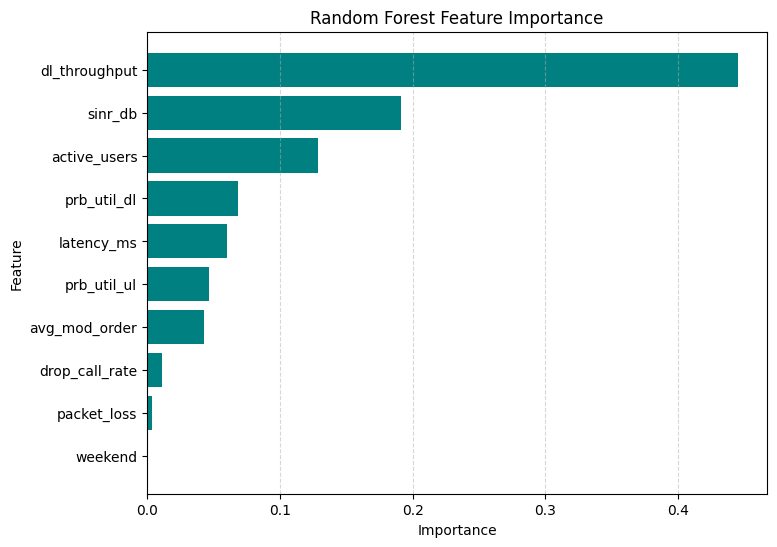

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(importance["Feature"], importance["Importance"], color="teal")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.show()

In [ ]:
# CHART INTERPRETATION
# 1. dl_throughput is the most important feature, the forest relied on it more than any other variable
# 2. sinr_db is the second most important
# 3. active_users is also important